In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [242]:
df = pd.read_csv("airbnb_data.csv")

In [243]:
df.head(1)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0


In [244]:
df.isnull().sum().sort_values(ascending=False)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_identity_verified      188
host_has_profile_pic        188
host_since                  188
beds                        131
bedrooms                     91
description                   0
city                          0
cleaning_fee                  0
cancellation_policy           0
accommodates                  0
bed_type                      0
room_type                     0
amenities                     0
id                            0
log_price                     0
property_type                 0
instant_bookable              0
longitude                     0
latitude                      0
number_of_reviews             0
name                          0
dtype: int64

In [245]:
print("Shape of Matrix:", df.shape)
print('--'*50)
print(df.columns)

Shape of Matrix: (74111, 29)
----------------------------------------------------------------------------------------------------
Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')


# Removing useless columns that is useless for linear regression

In [246]:
cols_to_drop = ['id','name','thumbnail_url','description']
df = df.drop(columns=cols_to_drop)
df.head(1)

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,f,18-07-2016,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0


# Removing useless special characters from amenities column and couting the amenties_counts 

In [247]:
df['amenities'] = df['amenities'].apply(lambda x: x.replace("{","").replace("}","").replace('"','').split(","))
df['amenities'] = df['amenities'].apply(lambda x: [a.strip() for a in x if "translation missing" not in a])
df['amenities_count'] = df['amenities'].apply(len)
df.drop(columns=['amenities'], inplace=True)

# Checking nulls

In [248]:
df.isnull().sum().sort_values(ascending=False)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
beds                        131
bedrooms                     91
bed_type                      0
accommodates                  0
room_type                     0
property_type                 0
log_price                     0
city                          0
cleaning_fee                  0
cancellation_policy           0
instant_bookable              0
latitude                      0
longitude                     0
number_of_reviews             0
amenities_count               0
dtype: int64

# Checking types of unique values in columns having null values 

In [249]:
numeric_cols = ['host_response_rate','review_scores_rating','first_review','last_review', 'bathrooms',
                'host_identity_verified','host_since','host_has_profile_pic','beds','bedrooms','zipcode']

for col in numeric_cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()}")
    print("Unique Values:", df[col].unique())
    print("-" * 80)

host_response_rate | Type: object | Nulls: 18299 | Filled: 55812
Unique Values: [nan '100%' '71%' '68%' '67%' '83%' '50%' '90%' '86%' '92%' '82%' '80%'
 '89%' '93%' '99%' '0%' '88%' '96%' '70%' '94%' '91%' '25%' '95%' '98%'
 '62%' '29%' '33%' '81%' '63%' '38%' '60%' '79%' '78%' '75%' '65%' '97%'
 '87%' '40%' '54%' '53%' '58%' '76%' '30%' '64%' '17%' '20%' '77%' '73%'
 '41%' '59%' '57%' '85%' '56%' '42%' '44%' '35%' '14%' '74%' '27%' '10%'
 '84%' '6%' '72%' '36%' '55%' '43%' '13%' '39%' '46%' '26%' '61%' '52%'
 '23%' '22%' '69%' '66%' '15%' '11%' '31%' '21%' '47%']
--------------------------------------------------------------------------------
review_scores_rating | Type: float64 | Nulls: 16722 | Filled: 57389
Unique Values: [100.  93.  92.  nan  40.  97.  99.  90.  89.  91.  88.  86.  72.  98.
  95.  96.  84.  80.  94.  87.  85.  70.  60.  75.  20.  76.  83.  82.
  78.  73.  55.  81.  67.  71.  77.  79.  47.  74.  68.  66.  63.  50.
  53.  65.  64.  27.  69.  30.  58.  35.  62.  49.  

# Handling null values

### Replacing string(num%) host_response_rate column to numeric num and replace null value to median

In [250]:
# Function to replace '%' to none and empty values replace by nan
def convert_percent(x):
    try:
        return float(str(x).replace('%',''))
    except:
        return np.nan
df['host_response_rate'] = df['host_response_rate'].apply(convert_percent)

#Calculate and Replace mull values with median
median_response = df['host_response_rate'].median()
df['host_response_rate'] = df['host_response_rate'].fillna(median_response)

### Numeric columns fills missing with median

In [251]:
numeric_cols = ['bathrooms', 'review_scores_rating', 'bedrooms', 'beds']
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

### Converting bool categorical data to 0/1 and replace null with mode

In [252]:
# Convert t/f to 1/0 and 
df['host_has_profile_pic'] = df['host_has_profile_pic'].map({'t':1,'f':0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t':1,'f':0})
# Replaces with mode
df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna(df['host_has_profile_pic'].mode()[0])
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])

# Replace null with unknown in Text column for neigbours

In [253]:
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown').str.strip()

# Feature Engineering for date columns: converting to number of days since today

In [254]:
# Converts Date columns from object to datetime DataType
df['first_review'] = pd.to_datetime(df['first_review'], dayfirst=True, errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors='coerce')
df['host_since'] = pd.to_datetime(df['host_since'], dayfirst=True, errors='coerce')

# Fill missing date values with median 
df['first_review'] = df['first_review'].fillna(df['first_review'].median())
df['last_review'] = df['last_review'].fillna(df['last_review'].median())
df['host_since'] = df['host_since'].fillna(df['host_since'].median())

today = pd.Timestamp('today')

# Convert date columns into numeric features
df['host_days_since'] = (today - df['host_since']).dt.days
df['days_since_first_review'] = (today - df['first_review']).dt.days
df['days_since_last_review'] = (today - df['last_review']).dt.days

# Dropping the original date columns
df.drop(['first_review', 'last_review', 'host_since'], axis=1, inplace=True)

# Using regex we identify valid zipcode contains 4 or 5 num and remove extra string values from it 

In [255]:
import re

def clean_zipcode(x):
    x = str(x).strip()
    x = re.sub(r'\s+', '', x)
    match = re.findall(r'\d{4,5}', x)
    if match:
        return match[0]
    else:
        return 0  # replace invalid with 0

df['zipcode'] = df['zipcode'].apply(clean_zipcode).astype(int)

In [256]:
# Fill missing date values with mode in zipcode 
df['zipcode'] = df['zipcode'].fillna(df['zipcode'].mode()[0])
print(df['zipcode'].nunique())

650


In [257]:
df.isnull().sum()

log_price                  0
property_type              0
room_type                  0
accommodates               0
bathrooms                  0
bed_type                   0
cancellation_policy        0
cleaning_fee               0
city                       0
host_has_profile_pic       0
host_identity_verified     0
host_response_rate         0
instant_bookable           0
latitude                   0
longitude                  0
neighbourhood              0
number_of_reviews          0
review_scores_rating       0
zipcode                    0
bedrooms                   0
beds                       0
amenities_count            0
host_days_since            0
days_since_first_review    0
days_since_last_review     0
dtype: int64

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   log_price                74111 non-null  float64
 1   property_type            74111 non-null  object 
 2   room_type                74111 non-null  object 
 3   accommodates             74111 non-null  int64  
 4   bathrooms                74111 non-null  float64
 5   bed_type                 74111 non-null  object 
 6   cancellation_policy      74111 non-null  object 
 7   cleaning_fee             74111 non-null  bool   
 8   city                     74111 non-null  object 
 9   host_has_profile_pic     74111 non-null  float64
 10  host_identity_verified   74111 non-null  float64
 11  host_response_rate       74111 non-null  float64
 12  instant_bookable         74111 non-null  object 
 13  latitude                 74111 non-null  float64
 14  longitude             

# Select Only numeric Columns for outliers detection

In [259]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['log_price', 'accommodates', 'bathrooms', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'latitude', 'longitude',
       'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms',
       'beds', 'amenities_count', 'host_days_since', 'days_since_first_review',
       'days_since_last_review'],
      dtype='object')


## Outliers detection for numeric columns

In [260]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

log_price                 :   2.07% outliers
accommodates              :   4.86% outliers
bathrooms                 :  21.34% outliers
host_has_profile_pic      :   0.30% outliers
host_identity_verified    :   0.00% outliers
host_response_rate        :  16.94% outliers
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers
review_scores_rating      :   6.24% outliers
zipcode                   :   0.00% outliers
bedrooms                  :  32.70% outliers
beds                      :   7.67% outliers
amenities_count           :   1.84% outliers
host_days_since           :   0.25% outliers
days_since_first_review   :   7.40% outliers
days_since_last_review    :  10.84% outliers


# visualizing the data and Handling outliers

## For discrete values best we can is cap the values from right side(tail side) as shown in the distribution plot to reduce the effect of outliers 
## We cap only the top 1% extreme values using the 99th percentile only for tail part.
# That Result
## - Keeps 99% data same
## - Removes extreme highs

# Bedrooms 32.70% outliers (Right Skewed)

Column 'bedrooms' unique values: [ 1.  3.  2.  0.  4.  5.  6.  7.  8.  9. 10.]


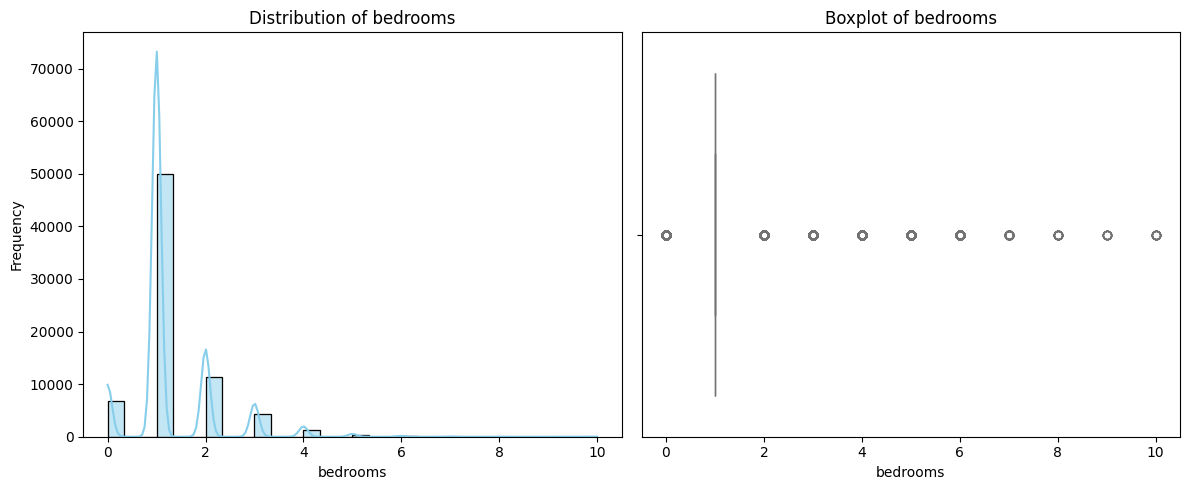

In [261]:
col = 'bedrooms'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [262]:
col = 'bedrooms'
upper_limit = df[col].quantile(0.99)
lower_limit = df[col].quantile(0.01)

df[col + '_capped'] = np.where(df[col] > upper_limit, upper_limit,
                        np.where(df[col] < lower_limit, lower_limit, df[col]))

Column 'bedrooms_capped' unique values: [1. 3. 2. 0. 4.]


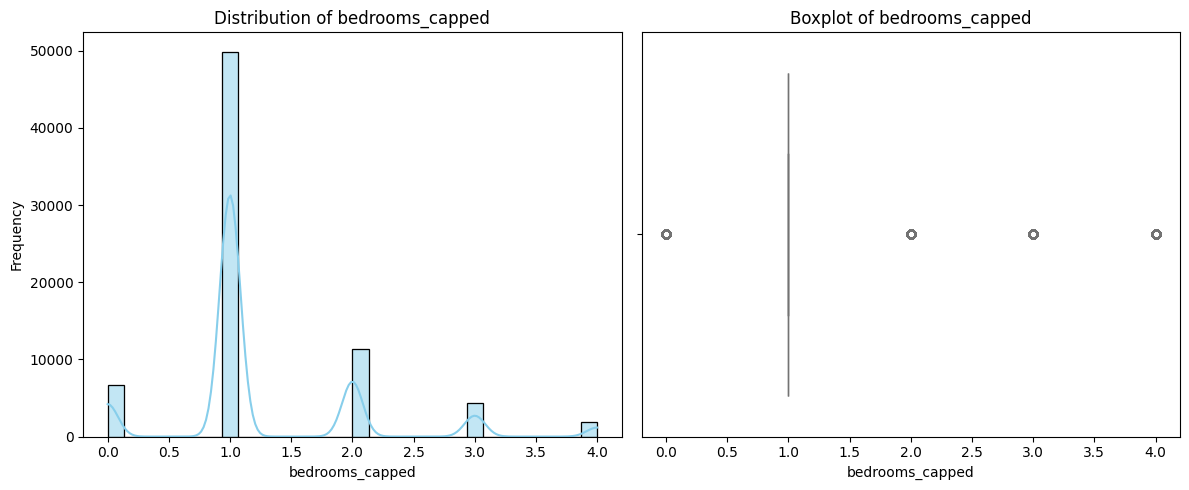

In [263]:
col = 'bedrooms_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

## bedrooms is discrete and skewed, it fits better in regression if we convert it into categories and use one-hot encoding

In [264]:
df['bedrooms_cat'] = df['bedrooms_capped'].astype(str)
df = pd.get_dummies(df, columns=['bedrooms_cat'], drop_first=True)

# bathrooms 21.34% outliers (Right SKewed)

Column 'bathrooms' unique values: [1.  1.5 2.  2.5 3.  0.5 4.5 5.  0.  4.  3.5 5.5 7.5 6.  8.  7.  6.5]


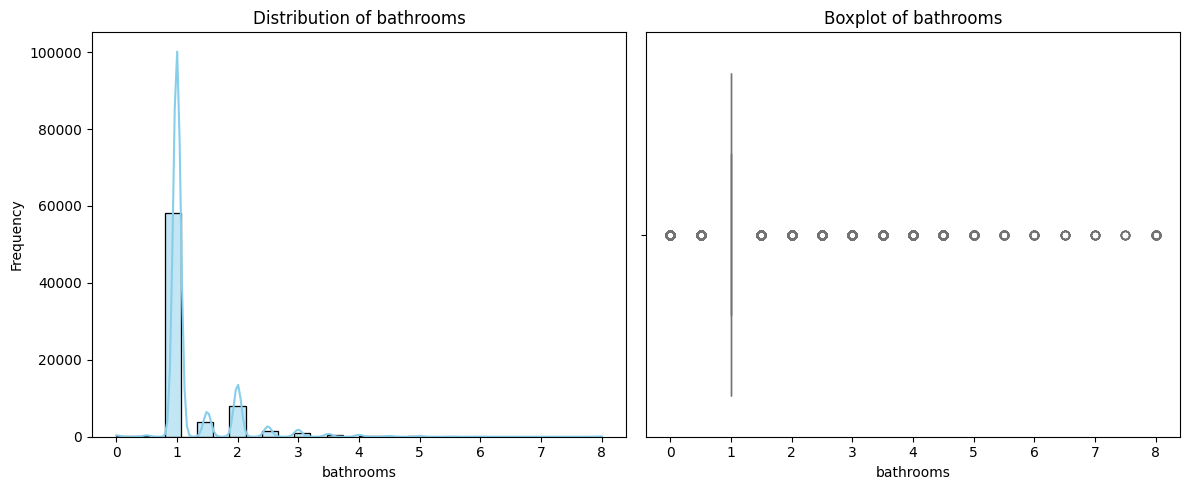

In [265]:
col = 'bathrooms'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

### Keeps 99% data same Removes extreme highs witrh 99% percentile

In [266]:
upper_limit = df['bathrooms'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['bathrooms_capped'] = np.where(df['bathrooms'] > upper_limit, upper_limit, df['bathrooms'])

99th Percentile (Upper Limit): 3.5


Column 'bathrooms_capped' unique values: [1.  1.5 2.  2.5 3.  0.5 3.5 0. ]


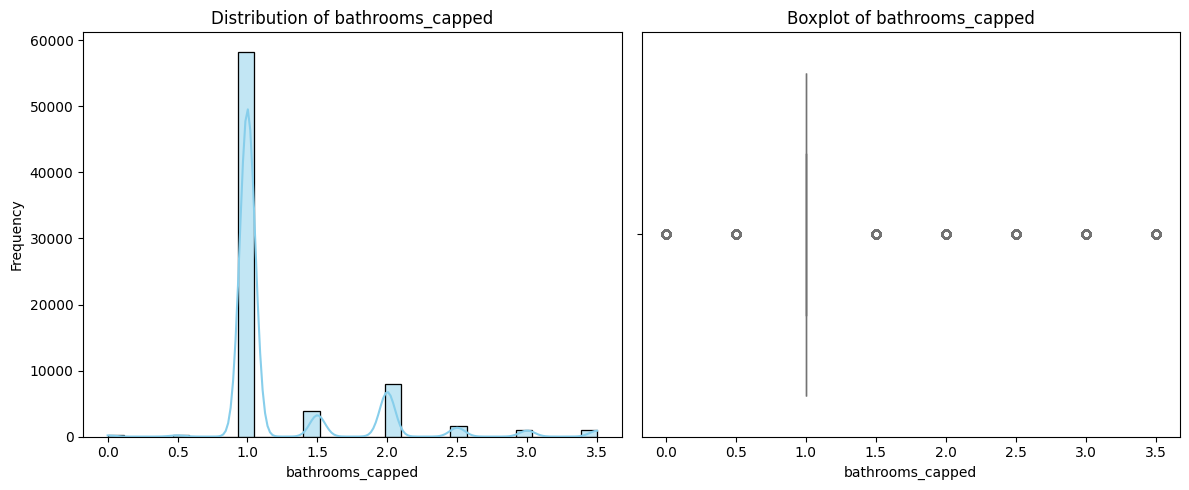

In [267]:
col = 'bathrooms_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# number_of_reviews 11.07% outliers

Column 'number_of_reviews' unique values: [  2   6  10   0   4   3  15   9 159  82  29  13  12  26   5  57  73  14
   1  40 248  46  17 138  11  44  34  85  18  31  30  19  25  22  23  28
   7  32 144  16  38 105  59  67  21 120   8  61  87 206  43 104  47  63
 186  36  27 167  48 102  51 126  81  58  72  68 107  79  98  39 187 123
  70  78  55  54  52  42  75 128  60  90 254 135  64  99 191  24  66 139
 125 129  74 318  33  35  37  20  93  83  45  41  49 289 190  62  88 127
 154 118 216 136  69 314 112  77  56 181  53 117 101 106 255 114 110 192
  76 113  91 182  84 146 119  86  50  71 157  95  94 158 142  97 194 173
 122 132 171 111 161 208 131 384 133 116 134 148  89 156 179 150 147 145
 202 258 178 200 155 163 149 267 100  65 207 242 172 121 180  80  92 263
 193 251 199 103 166 237 290 137 153  96 425 185 140 168 162 360 143 214
 141 246 217 195 196 109 273 305 351 152 189 269 221 317 218 336 272 175
 215 188 278 383 169 160 203 165 115 108 130 256 198 323 465 302 469 124
 220 204 

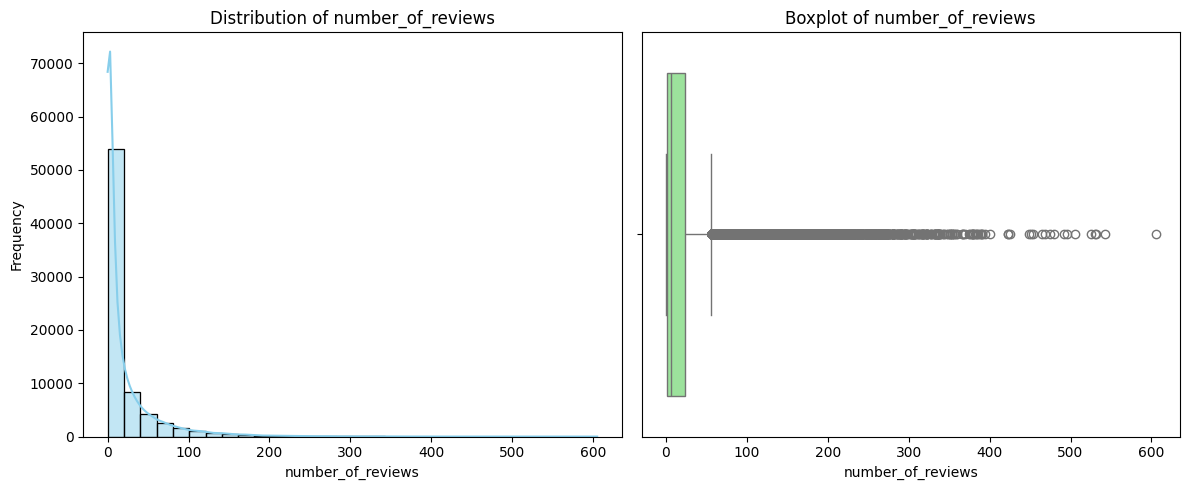

In [268]:
col = 'number_of_reviews'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Using log1p logarithmic transformation
## We don't use capping here because the values are very high, and it would affect the weightage in linear regression.
## Instead, we use log1p logarithmic transformation, to reduce the influence of large values in right-skewed data.
## It also safely handles zeros (since log(0) is undefined), compresses large values, and expands small values.

In [269]:
df['number_of_reviews_log1p'] = np.log1p(df['number_of_reviews'])

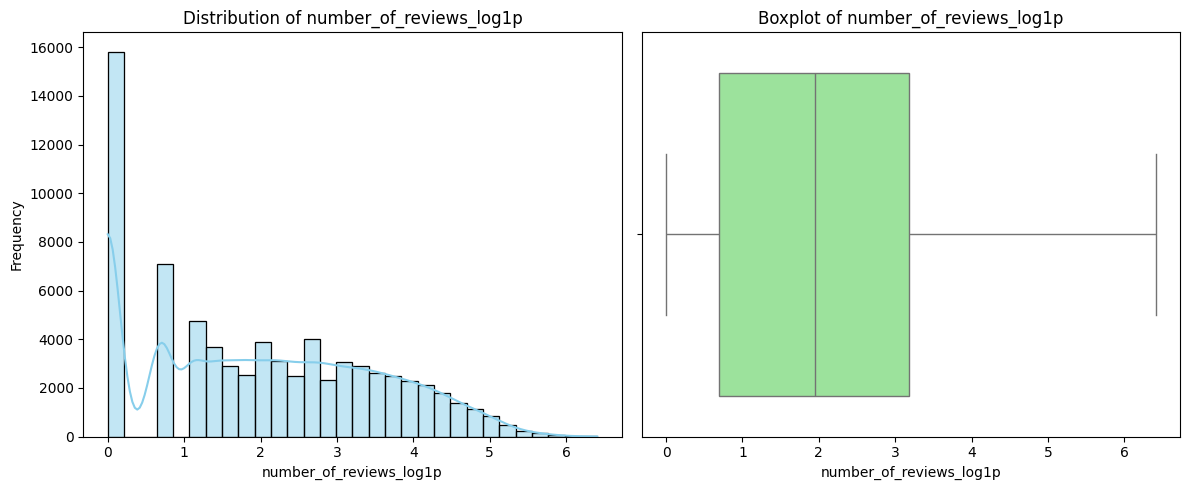

In [270]:
col = 'number_of_reviews_log1p'
# print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# days_since_last_review 10.84% outliers

Column 'days_since_last_review' unique values: [3372 2940 2949 ... 4141 4176 4305]


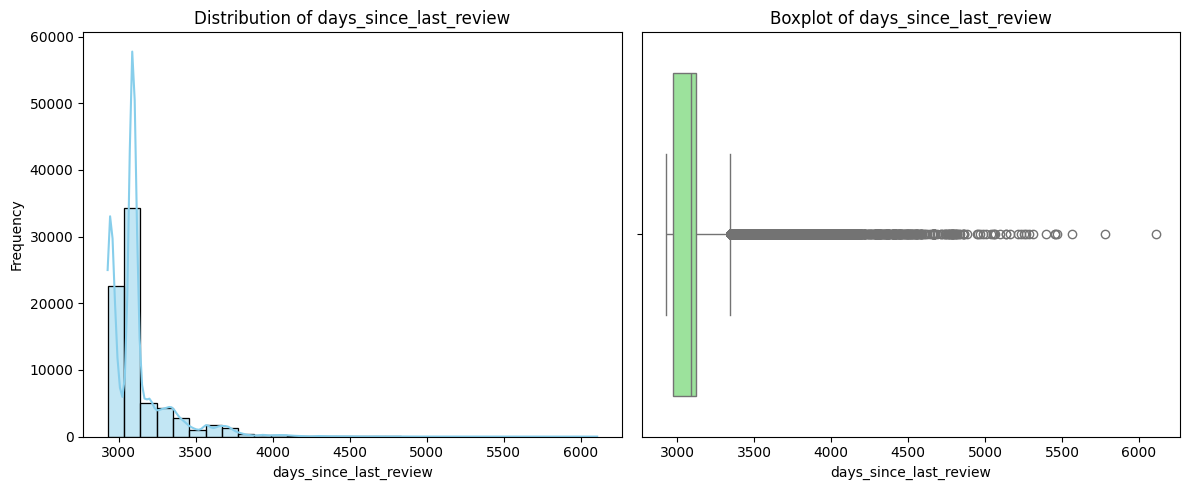

In [271]:
col = 'days_since_last_review'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [272]:
df['days_since_last_review_log1p'] = np.log1p(df['days_since_last_review'])

Column 'days_since_last_review_log1p' unique values: [8.12355784 7.98650494 7.98956045 ... 8.32893404 8.33734856 8.36776468]


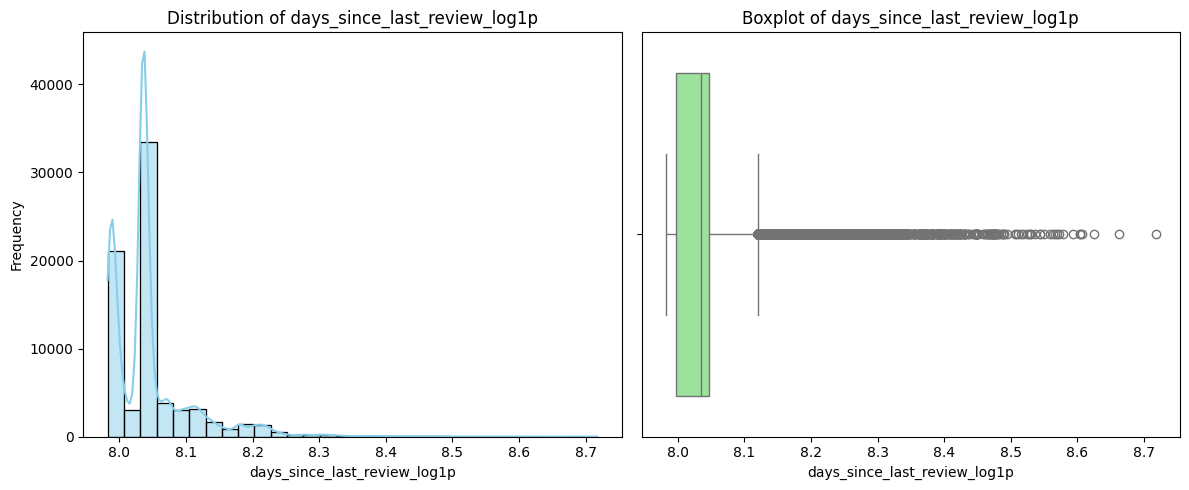

In [273]:
col = 'days_since_last_review_log1p'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# host_response_rate 16.94% outliers

Column 'host_response_rate' unique values: [100.  71.  68.  67.  83.  50.  90.  86.  92.  82.  80.  89.  93.  99.
   0.  88.  96.  70.  94.  91.  25.  95.  98.  62.  29.  33.  81.  63.
  38.  60.  79.  78.  75.  65.  97.  87.  40.  54.  53.  58.  76.  30.
  64.  17.  20.  77.  73.  41.  59.  57.  85.  56.  42.  44.  35.  14.
  74.  27.  10.  84.   6.  72.  36.  55.  43.  13.  39.  46.  26.  61.
  52.  23.  22.  69.  66.  15.  11.  31.  21.  47.]


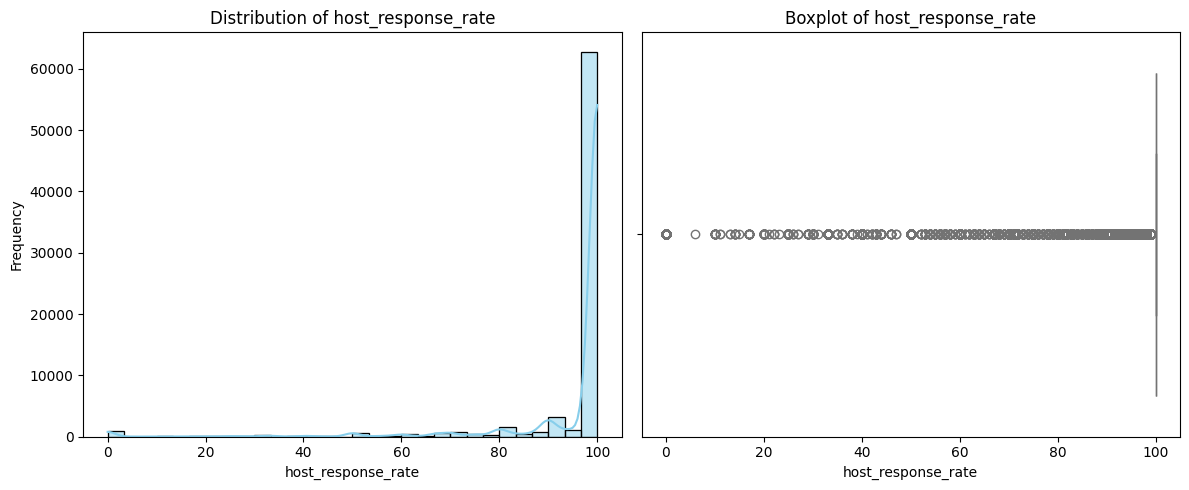

In [274]:
col = 'host_response_rate'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [275]:
df['host_response_rate_logged'] = np.log(df['host_response_rate'].max() + 1 - df['host_response_rate'])

Column 'host_response_rate_logged' unique values: [0.         3.40119738 3.49650756 3.52636052 2.89037176 3.93182563
 2.39789527 2.7080502  2.19722458 2.94443898 3.04452244 2.48490665
 2.07944154 0.69314718 4.61512052 2.56494936 1.60943791 3.4339872
 1.94591015 2.30258509 4.33073334 1.79175947 1.09861229 3.66356165
 4.27666612 4.21950771 2.99573227 3.63758616 4.14313473 3.71357207
 3.09104245 3.13549422 3.25809654 3.58351894 1.38629436 2.63905733
 4.11087386 3.8501476  3.87120101 3.76120012 3.21887582 4.26267988
 3.61091791 4.4308168  4.39444915 3.17805383 3.33220451 4.09434456
 3.73766962 3.78418963 2.77258872 3.80666249 4.07753744 4.04305127
 4.18965474 4.46590812 3.29583687 4.30406509 4.51085951 2.83321334
 4.55387689 3.36729583 4.17438727 3.8286414  4.06044301 4.47733681
 4.12713439 4.00733319 4.31748811 3.68887945 3.8918203  4.35670883
 4.36944785 3.4657359  3.55534806 4.4543473  4.49980967 4.24849524
 4.38202663 3.98898405]


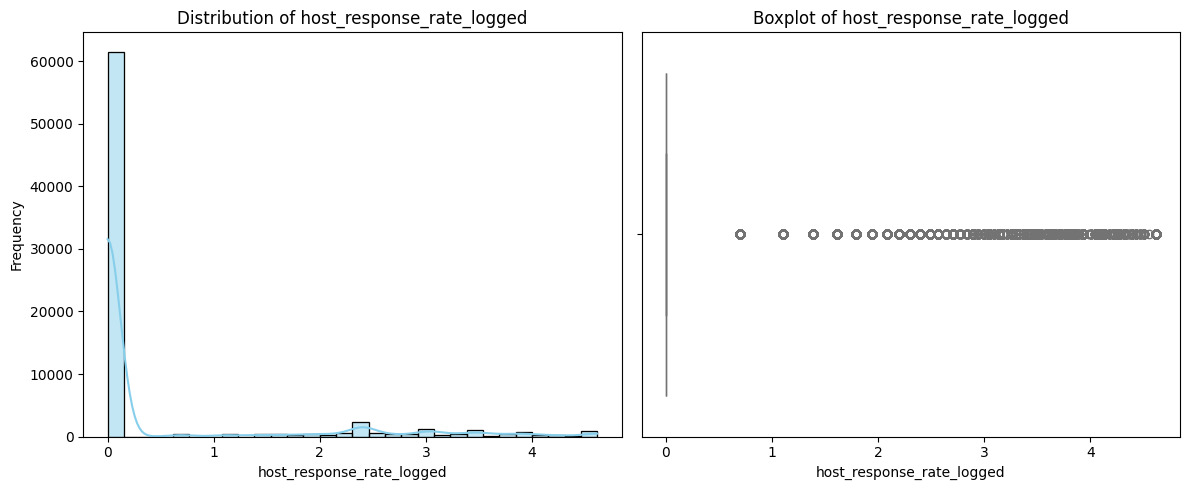

In [276]:
col = 'host_response_rate_logged'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

Column 'days_since_first_review' unique values: [3402 2989 3086 ... 4736 5240 5428]


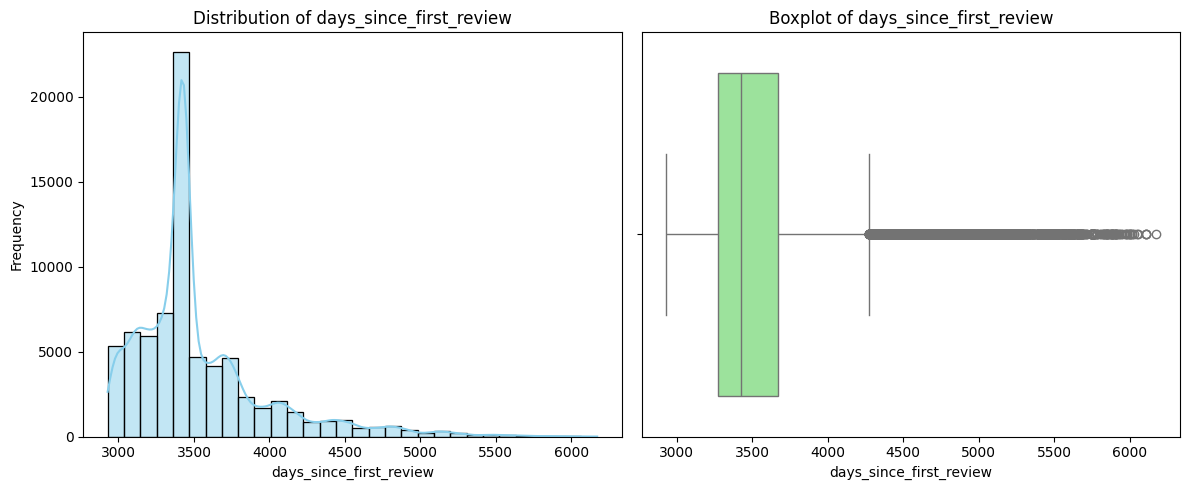

In [277]:
col = 'days_since_first_review'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [278]:
df['days_since_first_review_log1p'] = np.log1p(df['days_since_first_review'])

Column 'days_since_first_review_log1p' unique values: [8.13241267 8.00302867 8.03495502 ... 8.4631593  8.5642676  8.59951023]


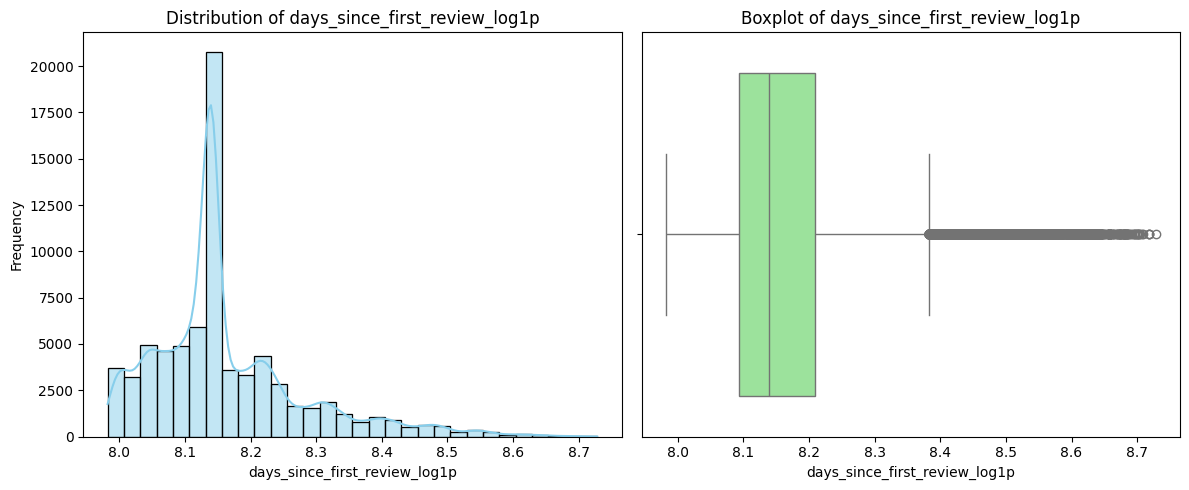

In [279]:
col = 'days_since_first_review_log1p'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

Column 'host_days_since' unique values: [4947 3036 3273 ... 6431 5643 5893]


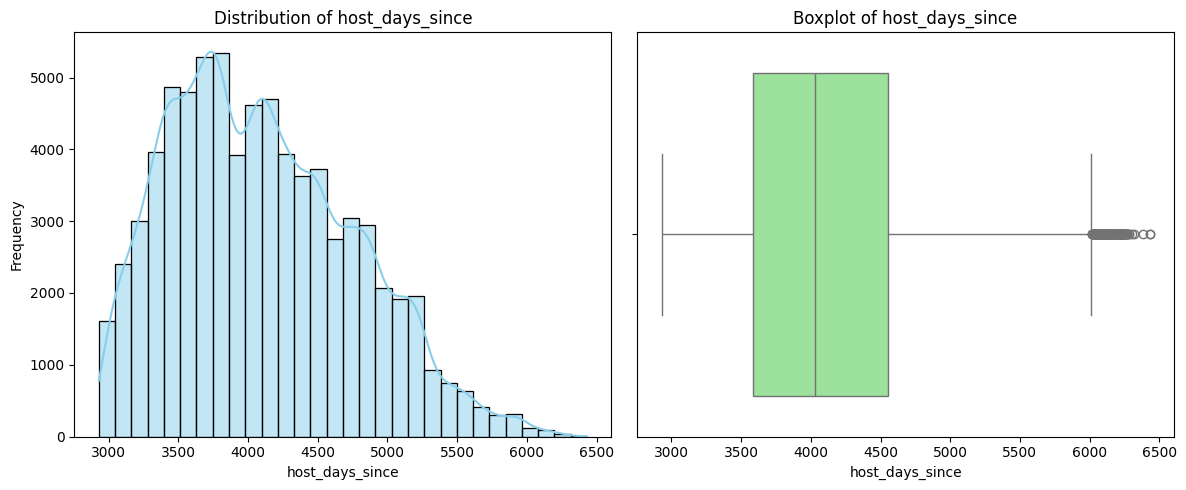

In [280]:
col = 'host_days_since'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [281]:
df['host_days_since_log1p'] = np.log1p(df['host_days_since'])

Column 'host_days_since_log1p' unique values: [8.50673873 8.01862547 8.09376776 ... 8.76904081 8.63834831 8.68169016]


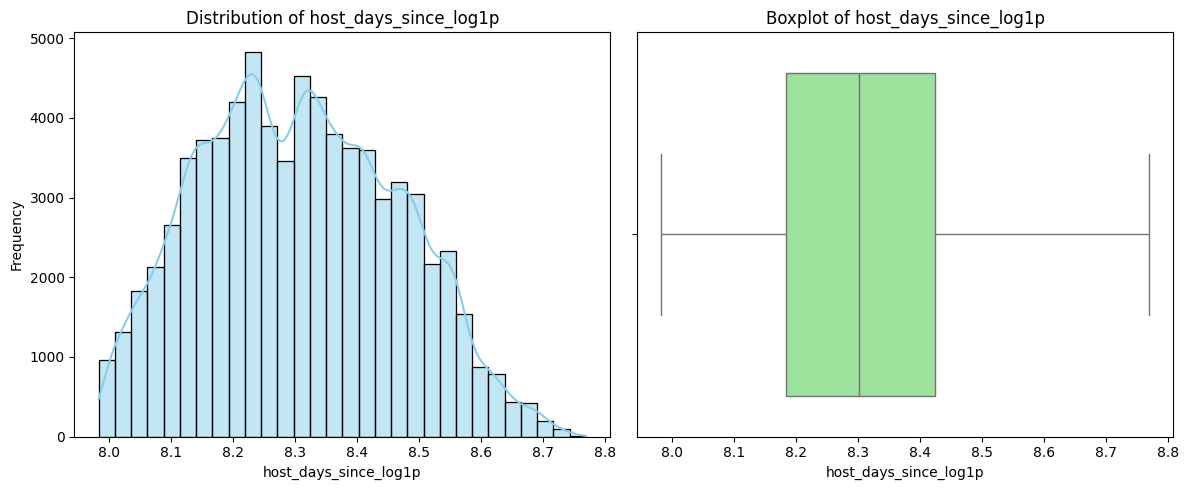

In [282]:
col = 'host_days_since_log1p'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

Column 'beds' unique values: [ 1.  3.  2.  7.  4.  6.  5. 10.  8. 16.  9. 13. 12. 11. 14. 15.  0. 18.]


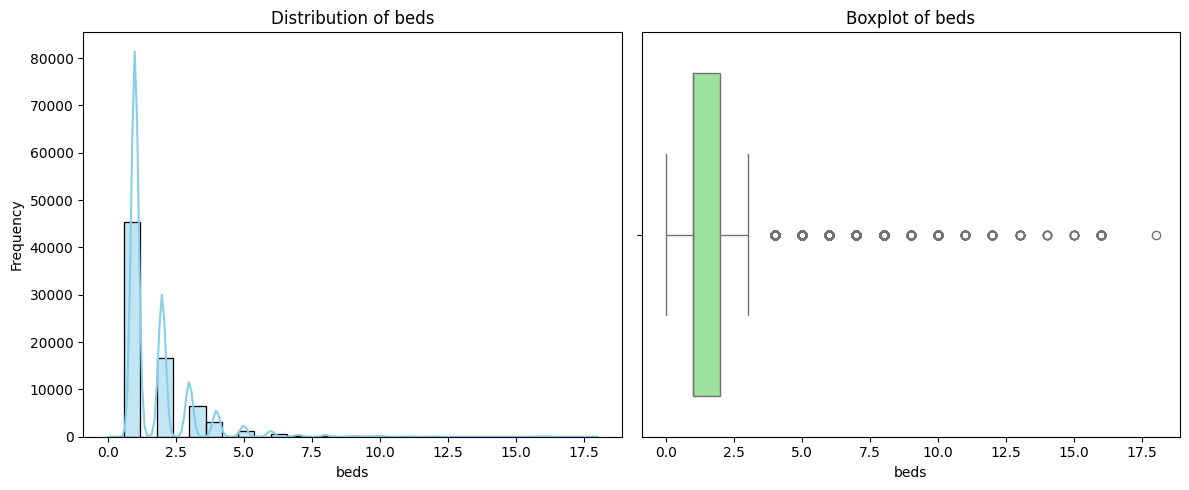

In [283]:
col = 'beds'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [284]:
upper_limit = df['beds'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['beds_capped'] = np.where(df['beds'] > upper_limit, upper_limit, df['beds'])

99th Percentile (Upper Limit): 6.0


Column 'beds_capped' unique values: [1. 3. 2. 6. 4. 5. 0.]


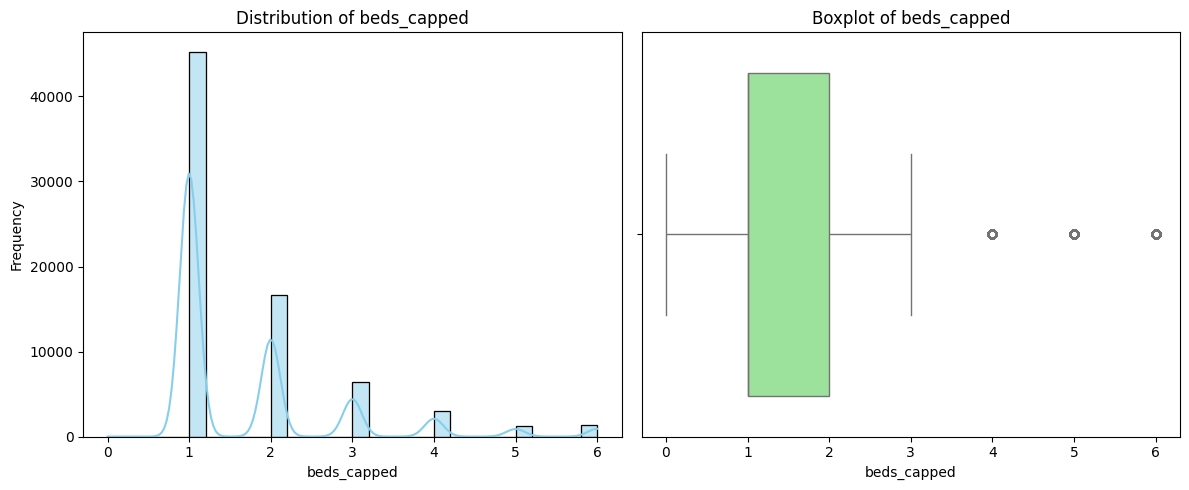

In [285]:
col = 'beds_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

Column 'accommodates' unique values: [ 3  7  5  4  2  6  8  1  9 10 16 11 12 14 13 15]


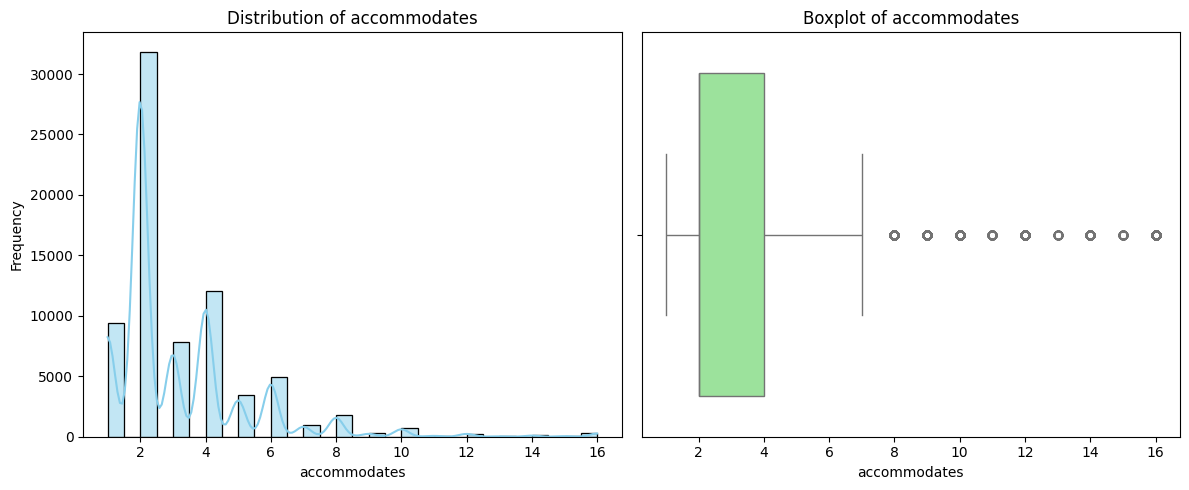

In [286]:
col = 'accommodates'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

In [287]:
upper_limit = df['accommodates'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['accommodates_capped'] = np.where(df['accommodates'] > upper_limit, upper_limit, df['accommodates'])

99th Percentile (Upper Limit): 12.0


Column 'accommodates_capped' unique values: [ 3.  7.  5.  4.  2.  6.  8.  1.  9. 10. 12. 11.]


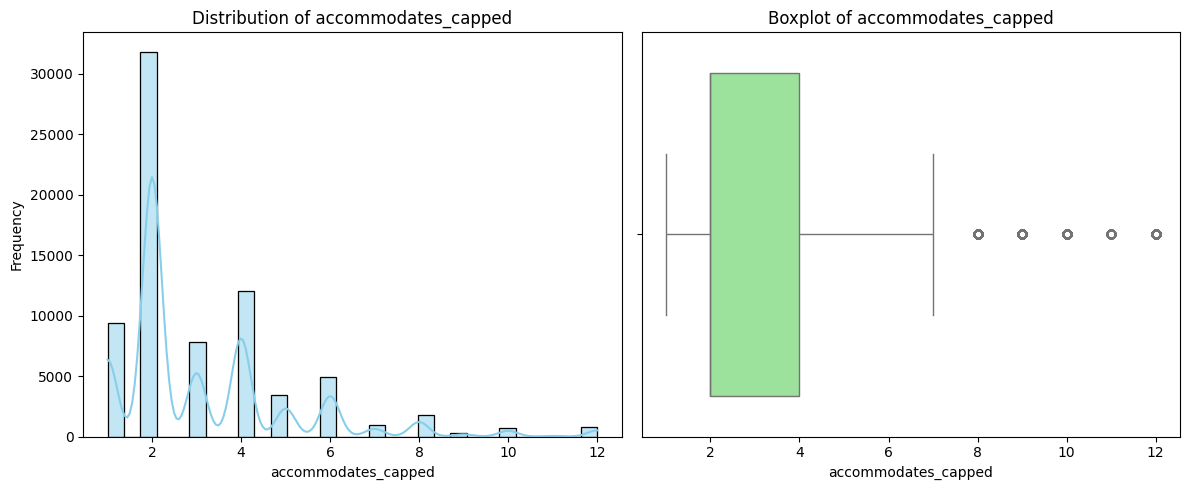

In [288]:
col = 'accommodates_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

log_price                 :   2.07% outliers
accommodates              :   4.86% outliers done
bathrooms                 :  21.34% outliers done
host_has_profile_pic      :   0.30% outliers
host_identity_verified    :   0.00% outliers
host_response_rate        :  16.94% outliers done
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers done
review_scores_rating      :   6.24% outliers
zipcode                   :   0.00% outliers
bedrooms                  :  32.70% outliers done
beds                      :   7.67% outliers done
amenities_count           :   1.84% outliers
host_days_since           :   0.25% outliers done
days_since_first_review   :   7.40% outliers done
days_since_last_review    :  10.84% outliers done

# Dropping original columns and keeping handled columns

In [289]:
cols_to_drop = ['bedrooms','bathrooms','number_of_reviews','days_since_last_review',
                'host_response_rate','days_since_first_review','host_days_since','accommodates', 'beds']

df.drop(columns=cols_to_drop, inplace=True)

# Applying Label Encoding for binary features data than can be 0/1

In [290]:
from sklearn.preprocessing import LabelEncoder

# Selects Categorical columns
label_cols = ['cancellation_policy','instant_bookable','host_has_profile_pic','host_identity_verified']

le = LabelEncoder()
for col in label_cols:
    df[col] = df[col].fillna('Unknown')  # missing values handle
    df[col] = le.fit_transform(df[col])

# Applying One-Hot Encode for nominal — no natural order, multiple categories.

In [291]:
# Selects columns
onehot_cols = ['property_type','room_type','bed_type','city','neighbourhood']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Columns: 688 entries, log_price to neighbourhood_Wrigleyville
dtypes: bool(669), float64(13), int64(6)
memory usage: 58.0 MB


In [293]:
df['host_has_profile_pic'].unique()

array([1, 0])

In [294]:
df['host_identity_verified'].unique()

array([1, 0])

In [295]:
X = df.drop(columns=['log_price'])
y = df['log_price']

# Split training and test data

In [296]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [297]:
my_lr = LinearRegression()
my_lr.fit(X_train, y_train)
y_pred = my_lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.3018
R²: 0.6692


# Standard Scaling

In [298]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

# Linear Regression

In [299]:
my_lr = LinearRegression()
my_lr.fit(X_train_scaled, y_train)
y_pred = my_lr.predict(X_test_scaled)

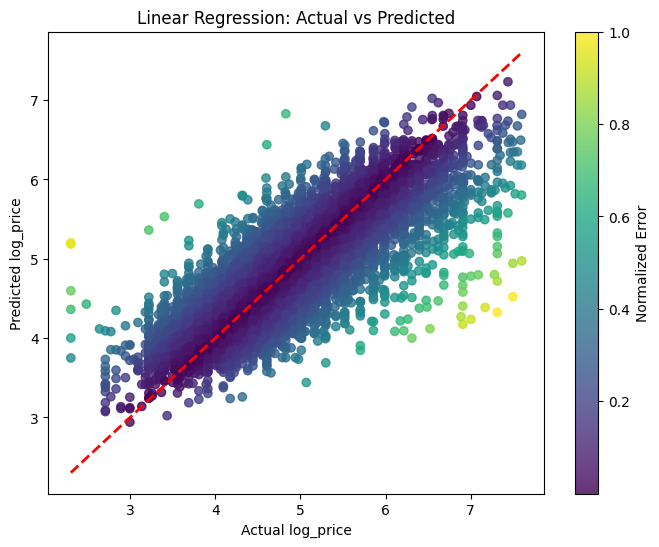

In [300]:
errors = np.abs(y_test - y_pred)
colors = errors / errors.max() 

plt.figure(figsize=(8,6))
scatter = plt.scatter(y_test, y_pred, c=colors, cmap='viridis', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) #draws perfet line linear regression
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Linear Regression: Actual vs Predicted')
plt.colorbar(scatter, label='Normalized Error')  # shows colors scale
plt.show()

In [301]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Linear Regression Performance:
MAE: 0.3018
R²: 0.6692
